In [17]:

import pandas as pd
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')
import seaborn as sns
import numpy as np

# Load the dataset
file_path = 'Daily activity metrics copy.csv'
data = pd.read_csv(file_path)

# # Convert 'Date' column to datetime format for consistency in time-based analysis
# data['Date'] = pd.to_datetime(data['Date'], format='%d-%m-%Y')
    


In [18]:
data.columns

Index(['Date', 'Move Minutes count', 'Calories (kcal)', 'Distance (m)',
       'Average heart rate (bpm)', 'Max heart rate (bpm)',
       'Min heart rate (bpm)', 'Average speed (m/s)', 'Max speed (m/s)',
       'Min speed (m/s)', 'Step count', 'Walking duration (ms)'],
      dtype='object')

In [19]:
from sklearn.linear_model import LinearRegression

# Drop rows with missing values in any of the three columns to train the model
complete_data = data.dropna(subset=['Move Minutes count', 'Calories (kcal)', 'Distance (m)',
       'Average heart rate (bpm)', 'Max heart rate (bpm)',
       'Min heart rate (bpm)', 'Average speed (m/s)', 'Max speed (m/s)',
       'Min speed (m/s)', 'Step count', 'Walking duration (ms)'])


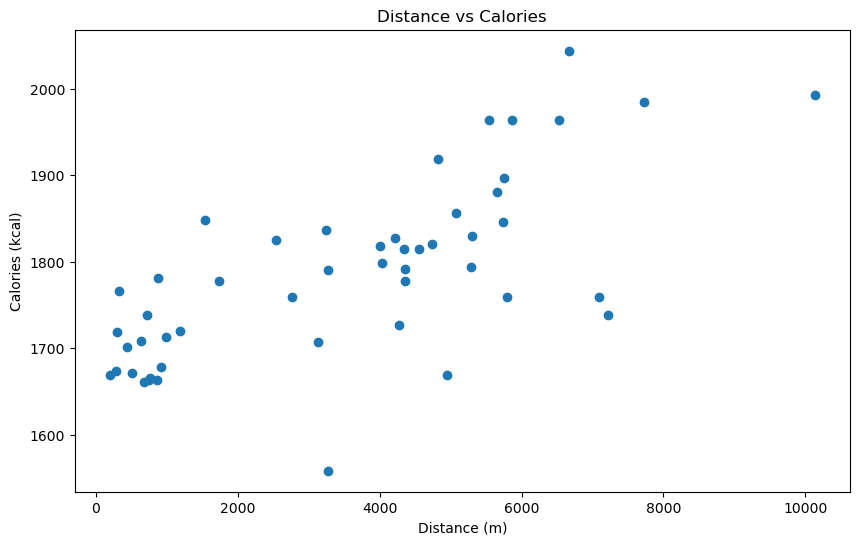

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(complete_data['Distance (m)'], complete_data['Calories (kcal)'])
plt.xlabel('Distance (m)')
plt.ylabel('Calories (kcal)')
plt.title('Distance vs Calories')
plt.show()


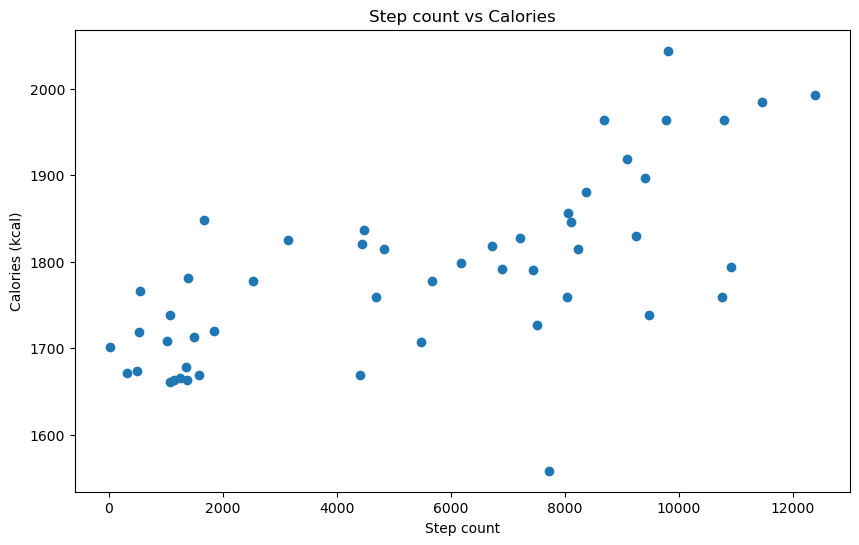

In [21]:

plt.figure(figsize=(10, 6))
plt.scatter(complete_data['Step count'], complete_data['Calories (kcal)'])
plt.xlabel('Step count')
plt.ylabel('Calories (kcal)')
plt.title('Step count vs Calories')
plt.show()

In [22]:

# Define the features and target for regression model
X = complete_data[['Move Minutes count', 'Distance (m)',
       'Average heart rate (bpm)', 'Max heart rate (bpm)',
       'Min heart rate (bpm)', 'Average speed (m/s)', 'Max speed (m/s)',
       'Min speed (m/s)', 'Step count', 'Calories (kcal)']]
y = complete_data['Walking duration (ms)']

# Train a linear regression model on the complete data
model = LinearRegression()
model.fit(X, y)


LinearRegression()

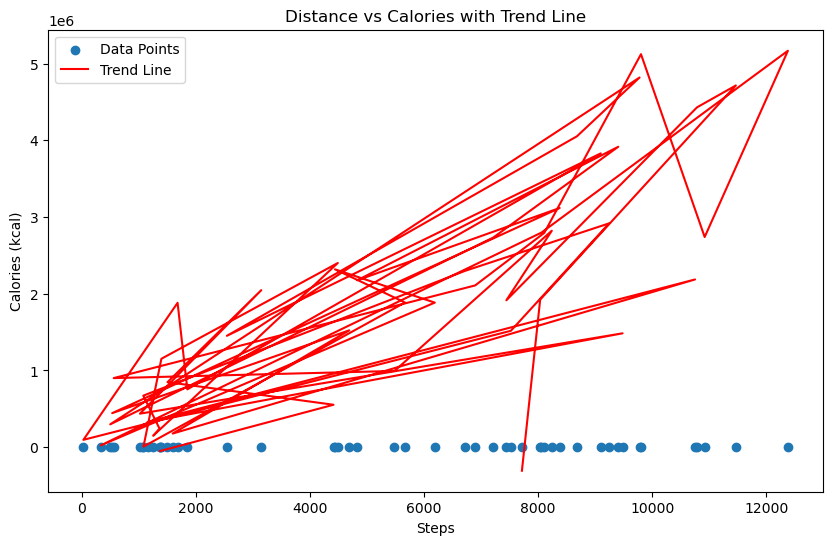

In [23]:
# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(complete_data['Step count'], complete_data['Calories (kcal)'], label='Data Points')

# Create trend line
trend_line = model.predict(X)
plt.plot(complete_data['Step count'], trend_line, color='red', label='Trend Line')

# Labels and title
plt.xlabel('Steps')
plt.ylabel('Calories (kcal)')
plt.title('Distance vs Calories with Trend Line')
plt.legend()
plt.show()

In [24]:
# Predict missing calories
missing_calories_data = data[data['Walking duration (ms)'].isna()]
missing_features = missing_calories_data[['Move Minutes count', 'Distance (m)',
	'Average heart rate (bpm)', 'Max heart rate (bpm)',
	'Min heart rate (bpm)', 'Average speed (m/s)', 'Max speed (m/s)',
	'Min speed (m/s)', 'Step count', 'Calories (kcal)']]

# Ensure there are no missing values in the features
missing_features = missing_features.dropna()

# Predict the calories for the rows with complete feature data
predicted_calories = model.predict(missing_features)
print(predicted_calories)

# Fill the missing values in the original dataset
data.loc[missing_features.index, 'Walking duration (ms)'] = predicted_calories

# Verify the filled data
data.head(10)

[-1294051.34039491 -1265334.14125374  -309336.36038931 -1025847.93500037
  -934927.35174191  -812847.13574332 -1282629.42909263  -799740.82646409
   -62061.60409917  -816729.06775801  -723906.80192623   436887.54020062
   364826.96679288   363058.01175768    17367.93486117   -11463.54393315
   339435.95431114   343663.08672214   112236.69119502   147371.80846545
    51454.05734811   508747.7325131    477269.41738794   720230.34127842
   636164.18367921   620342.42520982   176606.69206659  1070008.02348257
  1009394.15683217  1431232.73643934   -40960.71590417    87574.2703384 ]


,Date,Move Minutes count,Calories (kcal),Distance (m),Average heart rate (bpm),Max heart rate (bpm),Min heart rate (bpm),Average speed (m/s),Max speed (m/s),Min speed (m/s),Step count,Walking duration (ms)
0,12-08-2024,181.0,1454.5,4389.756115,88.933775,115.0,66.0,0.386543,0.478343,0.324931,10244.0,-1.294051e+06
1,13-08-2024,180.0,1454.5,4193.930564,83.816770,105.0,66.0,0.415036,0.509161,0.313160,11040.0,-1.265334e+06
2,14-08-2024,60.0,1454.5,1700.920657,85.792398,127.0,67.0,0.469593,0.469593,0.469593,10810.0,-3.093364e+05
3,15-08-2024,61.0,1454.5,3015.839024,79.345745,118.0,57.0,0.417125,0.540696,0.293554,8100.0,-1.025848e+06
4,17-08-2024,61.0,1454.5,1317.428951,84.850410,105.0,62.0,0.355202,0.355202,0.355202,8975.0,-9.349274e+05
5,21-08-2024,61.0,1454.5,2932.989752,87.556738,117.0,69.0,0.403163,0.524185,0.282142,9886.0,-8.128471e+05
6,22-08-2024,60.0,1454.5,1577.902041,92.114094,111.0,67.0,0.434965,0.434965,0.434965,4164.0,-1.282629e+06
7,23-08-2024,NaN,1454.5,1038.126482,86.245370,112.0,67.0,0.289687,0.289687,0.289687,8372.0,NaN
8,24-08-2024,60.0,1454.5,3244.302168,88.168269,119.0,65.0,0.450110,0.629579,0.270641,9759.0,-7.997408e+05
9,26-08-2024,60.0,1454.5,2885.916302,96.461538,116.0,65.0,0.400120,0.521693,0.278546,14663.0,-6.206160e+04


In [25]:
data.isna().sum()

Date                        1
Move Minutes count          3
Calories (kcal)             1
Distance (m)                1
Average heart rate (bpm)    1
Max heart rate (bpm)        1
Min heart rate (bpm)        1
Average speed (m/s)         1
Max speed (m/s)             1
Min speed (m/s)             1
Step count                  1
Walking duration (ms)       3
dtype: int64

In [26]:
# Create a copy of complete_data for smoothing
smoothed_data = complete_data.copy()

# Smooth the 'Calories (kcal)' column to follow the trend line
smoothed_data['Distance (m)'] = trend_line

# Verify the smoothed data
smoothed_data.head()

,Date,Move Minutes count,Calories (kcal),Distance (m),Average heart rate (bpm),Max heart rate (bpm),Min heart rate (bpm),Average speed (m/s),Max speed (m/s),Min speed (m/s),Step count,Walking duration (ms)
12,30-08-2024,88.0,1558.651338,-3.063447e+05,93.454545,122.0,66.0,0.522351,1.293584,0.261528,7715.0,758619.0
13,31-08-2024,142.0,1759.385401,1.923017e+06,93.951220,124.0,63.0,0.480490,1.454929,0.261528,8035.0,1652517.0
15,03-09-2024,197.0,1984.968236,4.713979e+06,86.155963,108.0,64.0,0.534038,1.411924,0.250158,11467.0,4731928.0
16,04-09-2024,147.0,1963.450251,4.428979e+06,85.685185,108.0,69.0,0.608777,1.419730,0.252373,10786.0,4401899.0
17,05-09-2024,101.0,1790.295327,1.914639e+06,88.304878,110.0,72.0,0.573502,1.680236,0.250158,7442.0,2162620.0


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Walking duration (ms)
Feature names seen at fit time, yet now missing:
- Calories (kcal)


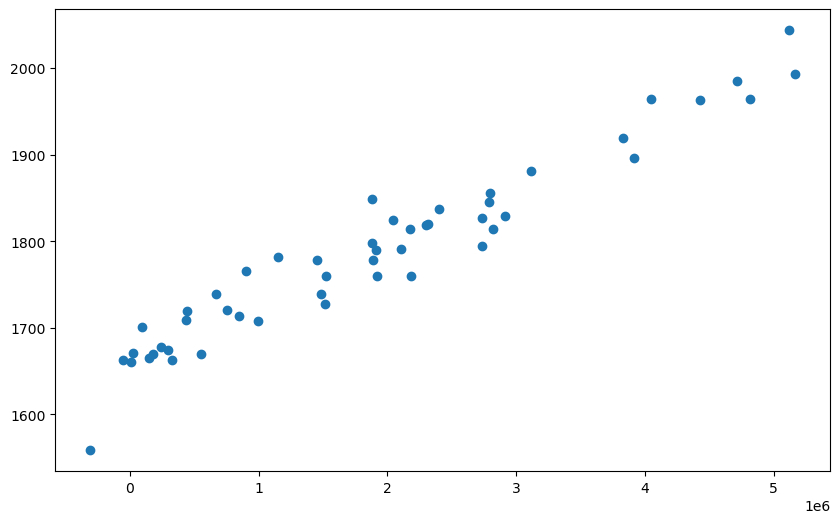

In [27]:
# Scatter plot of smoothed data
plt.figure(figsize=(10, 6))
plt.scatter(smoothed_data['Distance (m)'], smoothed_data['Calories (kcal)'], label='Smoothed Data Points')

# Create trend line for smoothed data
smoothed_trend_line = model.predict(smoothed_data[['Move Minutes count', 'Distance (m)',
	   'Average heart rate (bpm)', 'Max heart rate (bpm)',
	   'Min heart rate (bpm)', 'Average speed (m/s)', 'Max speed (m/s)',
	   'Min speed (m/s)', 'Step count', 'Walking duration (ms)']].dropna())

# Plot trend line
plt.plot(smoothed_data['Distance (m)'].dropna(), smoothed_trend_line, color='red', label='Trend Line')

plt.xlabel('Distance (m)')
plt.ylabel('Calories (kcal)')
plt.title('Smoothed Distance vs Calories with Trend Line')
plt.legend()
plt.show()

# Scatter plot of smoothed data for steps vs calories
plt.figure(figsize=(10, 6))
plt.scatter(smoothed_data['Step count'], smoothed_data['Calories (kcal)'], label='Smoothed Data Points')

# Create trend line for smoothed data
smoothed_trend_line_steps = model.predict(smoothed_data[['Move Minutes count', 'Distance (m)',
	   'Average heart rate (bpm)', 'Max heart rate (bpm)',
	   'Min heart rate (bpm)', 'Average speed (m/s)', 'Max speed (m/s)',
	   'Min speed (m/s)', 'Step count', 'Walking duration (ms)']].dropna())	

# Plot trend line
plt.plot(smoothed_data['Step count'].dropna(), smoothed_trend_line_steps, color='red', label='Trend Line')

plt.xlabel('Step count')
plt.ylabel('Calories (kcal)')
plt.title('Smoothed Step count vs Calories with Trend Line')
plt.legend()
plt.show()

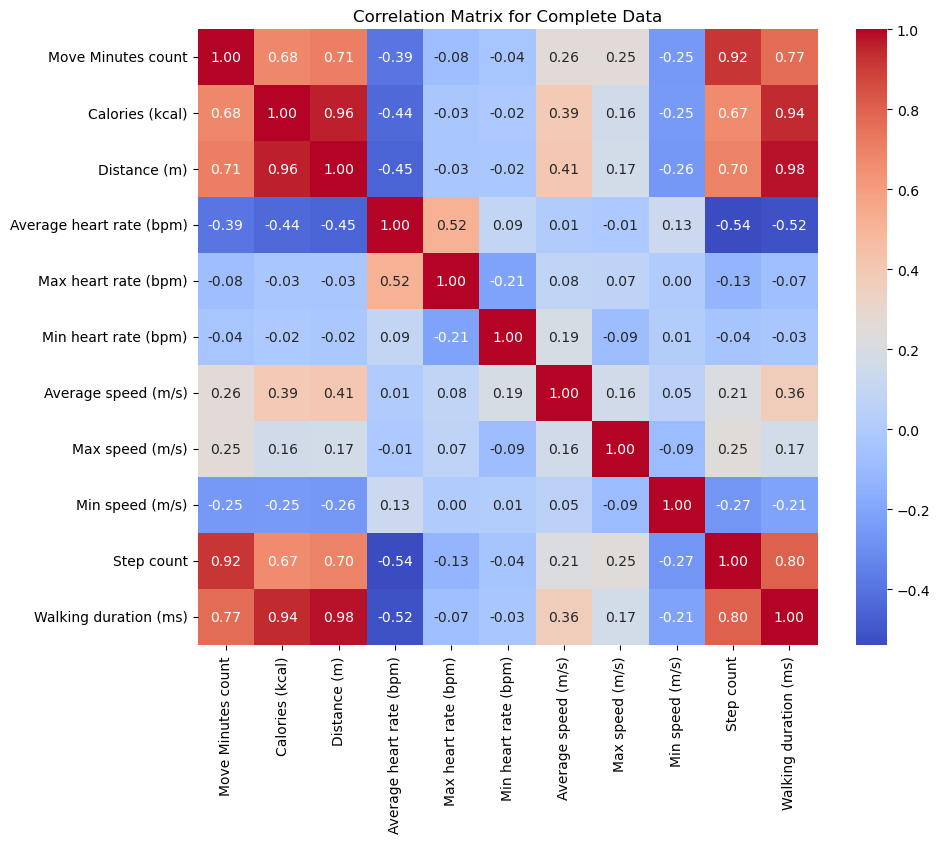

In [ ]:
corr_data=smoothed_data.drop(['Date'], axis=1)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix for Complete Data")
plt.show()
    

In [ ]:
#Save the DataFrame to a CSV file
data.to_csv('Daily_Activity_metrics_filled3.csv', index=False)

In [ ]:
data.head()

,Date,Move Minutes count,Calories (kcal),Distance (m),Average heart rate (bpm),Max heart rate (bpm),Min heart rate (bpm),Average speed (m/s),Max speed (m/s),Min speed (m/s),Step count,Walking duration (ms)
0,12-08-2024,181.0,1454.5,4389.756115,88.933775,115.0,66.0,0.386543,0.478343,0.324931,10244.0,-1.294051e+06
1,13-08-2024,180.0,1454.5,4193.930564,83.816770,105.0,66.0,0.415036,0.509161,0.313160,11040.0,-1.265334e+06
2,14-08-2024,60.0,1454.5,1700.920657,85.792398,127.0,67.0,0.469593,0.469593,0.469593,10810.0,-3.093364e+05
3,15-08-2024,61.0,1454.5,3015.839024,79.345745,118.0,57.0,0.417125,0.540696,0.293554,8100.0,-1.025848e+06
4,17-08-2024,61.0,1454.5,1317.428951,84.850410,105.0,62.0,0.355202,0.355202,0.355202,8975.0,-9.349274e+05
